# Data Understanding and Exploratory Data Analysis (EDA)

Notebook ini berfokus pada pemahaman awal dataset dan analisis eksplorasi.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## 1. Load Dataset

In [2]:
df = pd.read_csv('../data/bisniscom_2021-2022.csv', names=['category', 'date', 'title', 'image_url', 'url', 'content'])


## 2. Pemeriksaan Awal

In [3]:
print("Info Dataset:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplikasi Data:")
print(df.duplicated().sum())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29554 entries, 0 to 29553
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   category   29554 non-null  object
 1   date       29554 non-null  object
 2   title      29553 non-null  object
 3   image_url  29554 non-null  object
 4   url        29554 non-null  object
 5   content    29070 non-null  object
dtypes: object(6)
memory usage: 1.4+ MB

Missing Values:
category       0
date           0
title          1
image_url      0
url            0
content      484
dtype: int64

Duplikasi Data:
0


## 3. Distribusi Kategori Berita

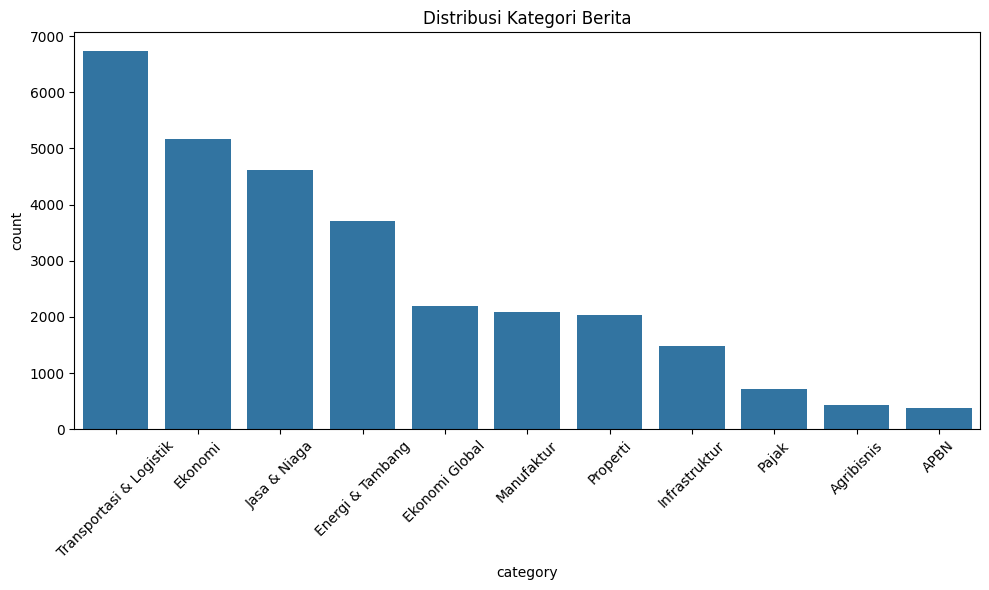

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)
plt.title('Distribusi Kategori Berita')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Analisis Panjang Teks

Menggabungkan `title` dan `content` untuk melihat distribusi panjang teks. Hal ini penting untuk menentukan `max_length` pada tokenisasi Deep Learning dan IndoBERT.

In [5]:
df['text'] = df['title'].fillna('') + ' ' + df['content'].fillna('')
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

df['text_length'].describe()

count    29554.000000
mean       336.234723
std        135.969436
min          5.000000
25%        257.000000
50%        313.000000
75%        387.000000
max       2670.000000
Name: text_length, dtype: float64

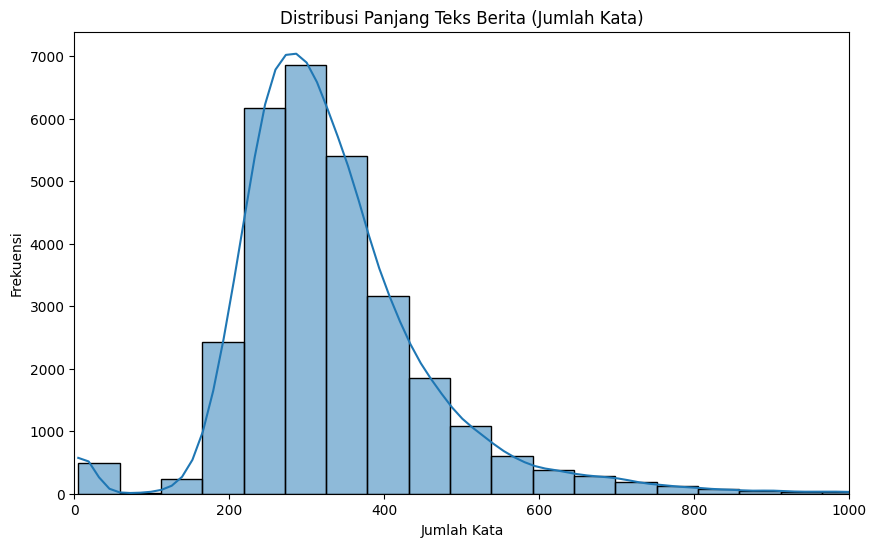

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribusi Panjang Teks Berita (Jumlah Kata)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 1000)
plt.show()